In [34]:
# ============================================
# 1. 导入依赖
# ============================================
import warnings
import os

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TQDM_DISABLE'] = '1'

import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import numpy as np

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler

# 定义特征列
FEATURES = ["temperature", "humidity", "wind_speed"]

In [35]:
import torch
print(torch.cuda.is_available())  # True
print(torch.cuda.device_count())  # 应该返回 6
print(torch.cuda.get_device_name(0))  # NVIDIA GeForce RTX 4090

True
6
NVIDIA GeForce RTX 4090


In [36]:
# ============================================
# 2. 连接 MySQL 并读取数据
# ============================================

db_config = {
    "host": "124.220.77.63",
    "user": "horeb",
    "password": "ZZYzzy4771430///",
    "database": "antarctic_data",
    "charset": "utf8mb4",
}

conn = mysql.connector.connect(**db_config)

query = """
SELECT station, record_time, temperature, humidity, wind_speed
-- wind_dir  # 暂时注释掉风向，因为数据有问题
FROM weather_data
ORDER BY record_time ASC
"""

df = pd.read_sql(query, conn)
conn.close()

# 转换时间列
df['record_time'] = pd.to_datetime(df['record_time'])

print(f"数据形状: {df.shape}")
print(f"时间范围: {df['record_time'].min()} 到 {df['record_time'].max()}")
print(f"站点数量: {df['station'].nunique()}")
print(f"各站点数据量:")
print(df['station'].value_counts())

df.head()

数据形状: (18149, 5)
时间范围: 2025-03-17 16:20:00 到 2025-10-27 17:05:00
站点数量: 6
各站点数据量:
station
长城站    5715
中山站    5338
秦岭站    2366
泰山站    2365
昆仑站    2363
黄河站       2
Name: count, dtype: int64


,station,record_time,temperature,humidity,wind_speed
0,长城站,2025-03-17 16:20:00,2.5,99,6.5
1,秦岭站,2025-03-17 23:29:00,-20.5,28,13.8
2,中山站,2025-03-17 23:31:00,-12.7,57,5.0
3,泰山站,2025-03-17 23:32:00,-40.0,69,13.6
4,昆仑站,2025-03-17 23:34:00,-60.5,51,0.0


长城站数据量: 5715
长城站时间范围: 2025-03-17 16:20:00 到 2025-10-27 17:05:00
长城站数据预览:
   station         record_time  temperature  humidity  wind_speed
0      长城站 2025-03-17 16:20:00          2.5        99         6.5
5      长城站 2025-03-17 23:50:00          3.7        93         7.7
7      长城站 2025-03-18 00:20:00          3.7        95         8.7
9      长城站 2025-03-18 00:50:00          4.0        95         5.5
11     长城站 2025-03-18 01:20:00          4.2        95         7.9


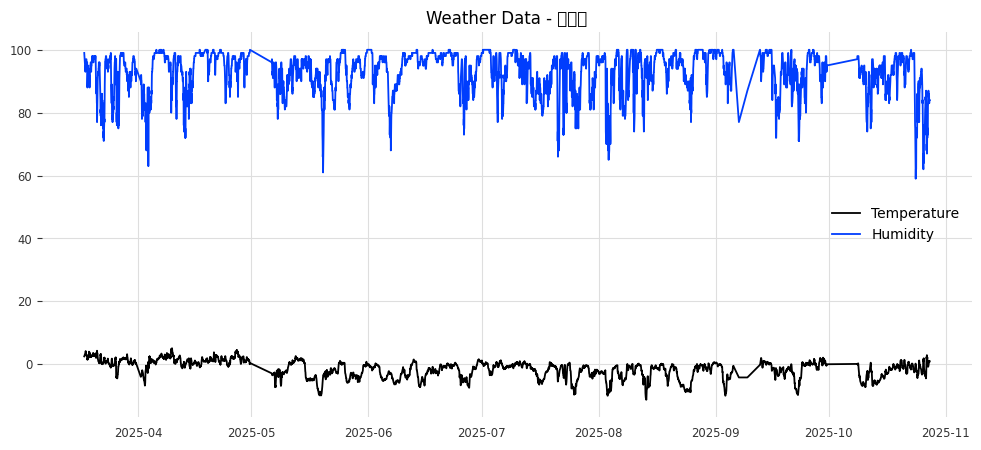

In [37]:
# ============================================
# 3. 数据可视化（单个站点示例）
# ============================================
station = "长城站"  # 要展示的气象站
df_station = df[df["station"] == station]

print(f"长城站数据量: {len(df_station)}")
print(f"长城站时间范围: {df_station['record_time'].min()} 到 {df_station['record_time'].max()}")
print(f"长城站数据预览:")
print(df_station.head())

plt.figure(figsize=(12, 5))
plt.plot(df_station['record_time'], df_station['temperature'], label='Temperature')
plt.plot(df_station['record_time'], df_station['humidity'], label='Humidity')
plt.title(f"Weather Data - {station}")
plt.legend()
plt.show()

训练数据形状: (5715, 5)
时间范围: 2025-03-17 16:20:00 到 2025-10-27 17:05:00
TimeSeries创建成功，长度: 64522


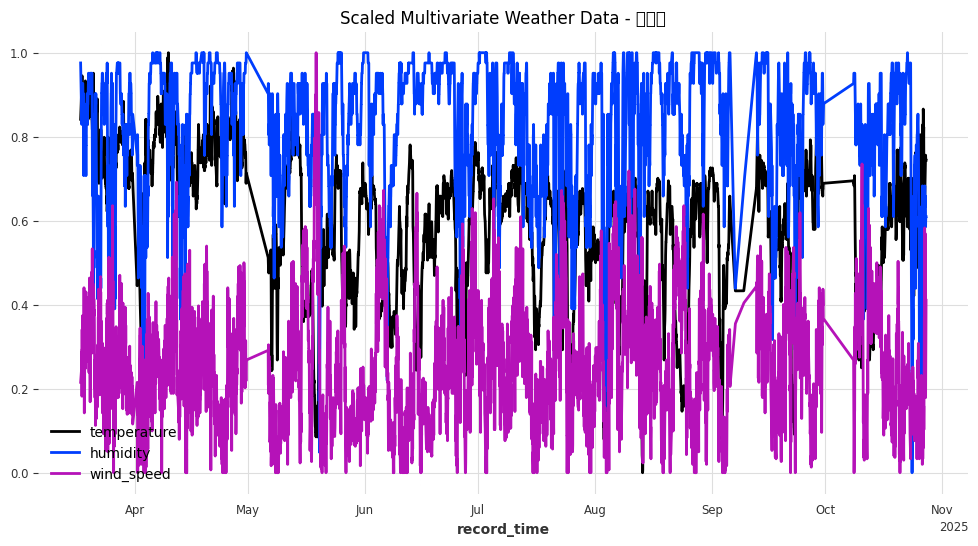

In [38]:
# ============================================
# 4. 转换为 Darts TimeSeries
# ============================================

# 选择一个站点训练
df_train = df[df["station"] == station].copy()
df_train = df_train.sort_values('record_time').reset_index(drop=True)

print(f"训练数据形状: {df_train.shape}")
print(f"时间范围: {df_train['record_time'].min()} 到 {df_train['record_time'].max()}")

# 时间列为 datetime. 去掉 tz 信息
df_train["record_time"] = pd.to_datetime(df_train["record_time"], errors="coerce").dt.tz_localize(None)

value_cols = FEATURES
df_train[value_cols] = df_train[value_cols].apply(pd.to_numeric, errors="coerce")

df_train = df_train.set_index("record_time")[value_cols].resample("5min").mean()
df_train = df_train.interpolate(method="time")
df_train = df_train.reset_index()

# 创建TimeSeries
series = TimeSeries.from_dataframe(
    df_train,
    time_col="record_time",
    value_cols=value_cols,
    fill_missing_dates=True,
    freq="5min"
)

print(f"TimeSeries创建成功，长度: {len(series)}")

# 方法1：原始TFT方法（Darts Scaler + 重采样）- 注释掉
# scaler = Scaler()
# series_scaled = scaler.fit_transform(series)

# 方法2：与LSTM保持一致的方法（MinMaxScaler + 原始数据）
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 手动进行MinMax标准化
scaler = MinMaxScaler()
data_values = df_train[value_cols].values
data_scaled = scaler.fit_transform(data_values)

# 创建标准化的DataFrame
df_scaled = df_train.copy()
df_scaled[value_cols] = data_scaled

# 创建TimeSeries - 需要指定频率，因为原始数据时间间隔不规则
series = TimeSeries.from_dataframe(
    df_scaled,
    time_col="record_time",
    value_cols=value_cols,
    fill_missing_dates=True,  # 需要填充缺失日期
    freq="5min"  # 指定5分钟频率，与原始方法保持一致
)

series_scaled = series

# 绘制图表
plt.figure(figsize=(12, 6))
series_scaled.plot()
plt.title(f"Scaled Multivariate Weather Data - {station}")
plt.show()


In [39]:
# ============================================
# 5. 划分训练集和验证集
# ============================================
# 方法1：原始TFT方法 - 使用最后7天作为验证集
# val_size = min(7 * 24 * 12, len(series_scaled) // 10)  # 7天或总数据的10%，取较小值

# 方法2：改进方法 - 使用最后200个点（与LSTM模型保持一致）
val_size = min(200, len(series_scaled) // 20)  # 最多200个点或5%，取较小值
train, val = series_scaled[:-val_size], series_scaled[-val_size:]

print(f"训练集长度: {len(train)}")
print(f"验证集长度: {len(val)}")
print(f"训练集时间范围: {train.start_time()} 到 {train.end_time()}")
print(f"验证集时间范围: {val.start_time()} 到 {val.end_time()}")


训练集长度: 64322
验证集长度: 200
训练集时间范围: 2025-03-17 16:20:00 到 2025-10-27 00:25:00
验证集时间范围: 2025-10-27 00:30:00 到 2025-10-27 17:05:00


In [ ]:
# ============================================
# 6. 定义并训练 TFT 模型
# ============================================
# 注意：这里已经修改了use_static_covariates=False，因为数据中没有静态协变量
model = TFTModel(
    input_chunk_length=24,   # 输入窗口 24 步
    output_chunk_length=6,   # 预测未来 6 步
    hidden_size=32,
    n_epochs=50,            # 训练轮数
    batch_size=16,
    add_relative_index=True,
    use_static_covariates=False,  # 关闭静态协变量，因为没有提供
    random_state=42,
    optimizer_kwargs={"lr": 0.001},  # 学习率
    lr_scheduler_cls=None,           # 不用调度器
    dropout=0.1,                     # dropout 防止过拟合
    force_reset=True,                # 每次训练重新初始化
    # pl_trainer_kwargs={
    #     "accelerator": "gpu",
    #     "devices": [0,1,2,3,4,5],
    #     "strategy": "ddp_notebook",   # ✅ notebook 安全版本
    # },
)

print("开始训练模型...")
print(f"训练数据形状: {train.all_values().shape}")
print(f"验证数据形状: {val.all_values().shape}")

model.fit(train, val_series=val, verbose=True)


开始训练模型...
训练数据形状: (64322, 3, 1)
验证数据形状: (200, 3, 1)


MisconfigurationException: `Trainer(strategy='ddp')` is not compatible with an interactive environment. Run your code as a script, or choose a notebook-compatible strategy: `Trainer(strategy='ddp_notebook')`. In case you are spawning processes yourself, make sure to include the Trainer creation inside the worker function.

In [ ]:
# ============================================
# 7. 预测并可视化
# ============================================
print("=== 开始预测 ===")
print(f"训练数据长度: {len(train)}")
print(f"验证数据长度: {len(val)}")

if model is None:
    print("❌ 模型未训练成功")
else:
    try:
        # 使用验证集进行预测
        print("使用验证集进行预测...")
        forecast = model.predict(n=len(val), series=train)

        print("✅ 预测完成")
        print(f"预测结果长度: {len(forecast)}")
        print(f"预测时间范围: {forecast.start_time()} 到 {forecast.end_time()}")

        forecast_values = forecast.all_values()
        print(f"预测数据统计: min={forecast_values.min():.4f}, max={forecast_values.max():.4f}, mean={forecast_values.mean():.4f}")

        if np.all(forecast_values == 0):
            print("⚠️ 警告：预测结果全为0")
        elif np.isnan(forecast_values).all():
            print("⚠️ 警告：预测结果全为NaN")

        # 绘制结果
        plt.figure(figsize=(15, 8))
        for i, col in enumerate(FEATURES):
            plt.subplot(2, 2, i+1)
            val_series = val.univariate_component(col)
            forecast_series = forecast.univariate_component(col)

            val_series.plot(label=f"actual {col}", color='blue', linewidth=2)
            forecast_series.plot(label=f"predict {col}", color='red', linewidth=2)

            plt.title(f"{col} - actual vs predict")
            plt.legend()
            plt.grid(True)

            # 数值范围
            plt.text(
                0.02, 0.98,
                f"actual scale: [{val_series.values().min():.2f}, {val_series.values().max():.2f}]\npredict scale: [{forecast_series.values().min():.2f}, {forecast_series.values().max():.2f}]",
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            )

        plt.tight_layout()
        plt.show()

        # 误差指标
        from darts.metrics import mae, mse
        print("\n=== 预测误差统计 ===")
        for col in FEATURES:
            actual = val.univariate_component(col)
            predicted = forecast.univariate_component(col)

            print(f"{col}: MAE={mae(actual, predicted):.4f}, MSE={mse(actual, predicted):.4f}")

    except Exception as e:
        print(f"❌ 预测失败: {e}")
        import traceback
        traceback.print_exc()


In [ ]:
# ============================================
# 8. 保存模型和Scaler
# ============================================
import pickle

# 保存模型
model.save("tft_model.pt")
print("✅ 模型已保存到 tft_model.pt")

# 保存 Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler 已保存到 scaler.pkl")

# 保存训练信息
training_info = {
    "station": station,
    "train_length": len(train),
    "val_length": len(val),
    "freq": "5min",
    "input_chunk_length": 24,
    "output_chunk_length": 6,
    "features": FEATURES
}
with open("training_info.pkl", "wb") as f:
    pickle.dump(training_info, f)
print("✅ 训练信息已保存到 training_info.pkl")

print("\n模型训练完成！")
print(f"训练集: {len(train)} 个数据点")
print(f"验证集: {len(val)} 个数据点")
print(f"特征: {training_info['features']}")


In [ ]:
# ============================================
# 9. 数据质量检查和诊断
# ============================================
print("=== 数据质量诊断 ===")

# 检查原始数据
print(f"原始数据形状: {df.shape}")
print(f"各站点数据量:")
station_counts = df['station'].value_counts()
print(station_counts)

# 检查时间间隔
print(f"\n时间间隔分析:")
for station_name in df['station'].unique()[:3]:  # 只检查前3个站点
    station_data = df[df['station'] == station_name].sort_values('record_time')
    if len(station_data) > 1:
        time_diffs = station_data['record_time'].diff().dropna()
        print(f"{station_name}: 平均间隔 {time_diffs.mean()}, 最小间隔 {time_diffs.min()}, 最大间隔 {time_diffs.max()}")

# 检查数值范围
print(f"\n数值范围检查:")
for col in FEATURES:
    print(f"{col}: 最小值={df[col].min():.2f}, 最大值={df[col].max():.2f}, 平均值={df[col].mean():.2f}")

# 检查缺失值
print(f"\n缺失值统计:")
print(df.isnull().sum())
